<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

خواندن دیتاست موردنیاز از سایت Kaggle

</div>


In [ ]:
from google.colab import files
files.upload()
!pip install -q kaggle seaborn scikit-learn
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d aealemran/thesis-dataset2
!unzip -q thesis-dataset2.zip -d driver_dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aealemran/thesis-dataset2
License(s): other
 96% 460M/481M [00:06<00:00, 92.8MB/s]
100% 481M/481M [00:06<00:00, 81.3MB/s]


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

اطلاعات کلی دیتاست در یک نگاه

</div>


In [ ]:
import os, shutil, random
dataset_root = "driver_dataset/Thesis_dataset2" 
if not os.path.exists(dataset_root):
    dataset_root = "driver_dataset"

classes = sorted([c for c in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, c))])
print("Classes found:", classes)
for cls in classes:
    cls_path = os.path.join(dataset_root, cls)
    num_images = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    print(f"Class {cls}: {num_images} images")

Classes found: ['DangerousDriving', 'Distracted', 'Drinking', 'Openeye', 'SafeDriving', 'Yawn', 'closed']
Class DangerousDriving: 2478 images
Class Distracted: 1672 images
Class Drinking: 2099 images
Class Openeye: 2000 images
Class SafeDriving: 2203 images
Class Yawn: 2731 images
Class closed: 1233 images


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

درست کردن یک زیرمجموعه از دیتاست برای آموزش مدل کم نمونه

</div>


In [ ]:
# Create subset
subset_dir = "driver_subset"
os.makedirs(subset_dir, exist_ok=True)
num_per_class = 200
for cls in classes:
    cls_path = os.path.join(dataset_root, cls)
    images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    if len(images) == 0:
        continue
    selected = random.sample(images, min(len(images), num_per_class))
    cls_out_path = os.path.join(subset_dir, cls)
    os.makedirs(cls_out_path, exist_ok=True)
    for img in selected:
        shutil.copy(os.path.join(cls_path, img), cls_out_path)
print("Subset created at:", subset_dir)


Subset created at: driver_subset


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ساخت مجموعه های train-validation-test برای ارزیابی مدل

</div>


In [ ]:
import numpy as np
train_dir = "driver_split/train"
val_dir = "driver_split/val"
test_dir = "driver_split/test"
for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)

for cls in classes:
    imgs = [f for f in os.listdir(os.path.join(subset_dir, cls)) if os.path.isfile(os.path.join(subset_dir, cls, f))]
    np.random.shuffle(imgs)
    n = len(imgs)
    if n == 0:
        continue
    train_idx = int(0.6 * n)
    val_idx = int(0.8 * n)
    splits = {
        train_dir: imgs[:train_idx],
        val_dir: imgs[train_idx:val_idx],
        test_dir: imgs[val_idx:]
    }
    for split_name, split_images in splits.items():
        cls_out = os.path.join(split_name, cls)
        os.makedirs(cls_out, exist_ok=True)
        for img in split_images:
            shutil.copy(os.path.join(subset_dir, cls, img), cls_out)
print("Train/Val/Test split ready at driver_split/")


Train/Val/Test split ready at driver_split/


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ساخت فرم استاندارد برای یادگیری کم نمونه:<br>
1.ایجاد support-set(
با فرم کلی 7 کلاس)<br>
2. ایجاد query-set

</div>


In [ ]:

import torch
from torch.utils.data import Dataset
from PIL import Image

class FewShotDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.classes = sorted([c for c in os.listdir(root) if os.path.isdir(os.path.join(root, c))])
        self.class_to_images = {cls: [os.path.join(root, cls, f) for f in os.listdir(os.path.join(root, cls)) if os.path.isfile(os.path.join(root, cls, f))]
                                 for cls in self.classes}

    def sample_episode(self, N_way=7, K_shot=5, Q_query=15):
        selected_classes = random.sample(self.classes, N_way)
        support_images, support_labels, query_images, query_labels = [], [], [], []
        for label, cls in enumerate(selected_classes):
            imgs = random.sample(self.class_to_images[cls], K_shot + Q_query)
            support, query = imgs[:K_shot], imgs[K_shot:]
            support_images.extend(support)
            support_labels.extend([label] * K_shot)
            query_images.extend(query)
            query_labels.extend([label] * Q_query)
        return support_images, support_labels, query_images, query_labels


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ایجاد معماری transformer مورد نیاز برای مدل FEAT

</div>


In [ ]:

from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((84, 84)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ساخت مدل Con4

</div>


In [ ]:

import torch.nn as nn
import torch.nn.functional as F

class Conv4(nn.Module):
    def __init__(self, x_dim=3, hid_dim=64, z_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(x_dim, hid_dim, 3, padding=1),
            nn.BatchNorm2d(hid_dim), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(hid_dim, hid_dim, 3, padding=1),
            nn.BatchNorm2d(hid_dim), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(hid_dim, hid_dim, 3, padding=1),
            nn.BatchNorm2d(hid_dim), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(hid_dim, z_dim, 3, padding=1),
            nn.BatchNorm2d(z_dim), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

def compute_prototypes(emb_support, support_labels, N_way, K_shot):
    prototypes = []
    for cls in range(N_way):
        mask = support_labels == cls
        if mask.sum() == 0:
            prototypes.append(torch.zeros(emb_support.size(1), device=emb_support.device))
        else:
            prototypes.append(emb_support[mask].mean(0))
    return torch.stack(prototypes)

def prototypical_loss(prototypes, emb_query, query_labels):
    dists = torch.cdist(emb_query, prototypes)
    log_p = F.log_softmax(-dists, dim=1)
    loss = F.nll_loss(log_p, query_labels)
    preds = (-dists).argmax(dim=1)
    acc = (preds == query_labels).float().mean().item()
    return loss, acc


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ساخت مدل FEAT

</div>


In [ ]:

class PrototypeTransformer(nn.Module):
    def __init__(self, embed_dim=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout, activation='relu', batch_first=False)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, prototypes):
        src = prototypes.unsqueeze(1)      # (N_way, 1, E)
        out = self.transformer(src)        # (N_way, 1, E)
        out = out.squeeze(1)               # (N_way, E)
        out = self.norm(out)
        return out

def compute_prototypes_for_feat(emb_support, support_labels, N_way):
    prototypes = []
    for cls in range(N_way):
        mask = (support_labels == cls)
        if mask.sum() == 0:
            prototypes.append(torch.zeros(emb_support.size(1), device=emb_support.device))
        else:
            prototypes.append(emb_support[mask].mean(0))
    return torch.stack(prototypes)

def prototypical_loss_feat(prototypes, emb_query, query_labels):
    dists = torch.cdist(emb_query, prototypes)
    log_p = F.log_softmax(-dists, dim=1)
    loss = F.nll_loss(log_p, query_labels)
    preds = (-dists).argmax(dim=1)
    acc = (preds == query_labels).float().mean().item()
    return loss, acc


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

خواندن دیتاست های لازم برای آموزش مدل ها

</div>


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
train_dataset = FewShotDataset("driver_split/train", transform=transform)
val_dataset   = FewShotDataset("driver_split/val", transform=transform)
test_dataset  = FewShotDataset("driver_split/test", transform=transform)


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

مقداردهی پارامتر های موثر برای بهبود مدل

</div>


In [ ]:

N_way = 7
Q_query = 15
episodes = 300
K_shot_list = [1,5,10]

model = Conv4().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

feat_model = Conv4().to(device)
feat_adapter = PrototypeTransformer().to(device)
optimizer_feat = torch.optim.Adam(list(feat_model.parameters()) + list(feat_adapter.parameters()), lr=1e-3, weight_decay=1e-5)
feat_episodes = 300
feat_K_shot_list = [1,5,10]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

درست کردن فرمت عکس ها برای دادن مقدار ورودی به ماشین

</div>


In [ ]:
def load_images(image_paths, transform):
    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        if transform:
            img = transform(img)
        images.append(img)
    return torch.stack(images)


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ایجاد تابع برای حساب کردن متغیرهای مربوط به ارزیابی
</div>


In [ ]:

@torch.no_grad()
def evaluate_few_shot(model, feat_adapter, feature_extractor, dataset, N_way, K_shot, Q_query, episodes_eval=50, is_feat=False):
    model.eval()
    if feature_extractor is not None:
        feature_extractor.eval()

    total_loss = 0.0
    total_acc = 0.0
    for _ in range(episodes_eval):
        support_paths, support_labels, query_paths, query_labels = dataset.sample_episode(N_way=N_way, K_shot=K_shot, Q_query=Q_query)
        support_images = load_images(support_paths, transform).to(device)
        query_images   = load_images(query_paths, transform).to(device)
        support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
        query_labels_t   = torch.tensor(query_labels, dtype=torch.long).to(device)

        if is_feat:
            emb_support = feature_extractor(support_images)
            emb_query   = feature_extractor(query_images)
            prototypes_init = compute_prototypes_for_feat(emb_support, support_labels_t, N_way)
            prototypes_adapted = feat_adapter(prototypes_init)
            loss_v, acc_v = prototypical_loss_feat(prototypes_adapted, emb_query, query_labels_t)
        else:
            emb_support = model(support_images)
            emb_query   = model(query_images)
            prototypes = compute_prototypes(emb_support, support_labels_t, N_way, K_shot)
            loss_v, acc_v = prototypical_loss(prototypes, emb_query, query_labels_t)

        total_loss += loss_v.item()
        total_acc += acc_v

    return total_loss / episodes_eval, total_acc / episodes_eval


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">

ذخیره سازی متغیرهای ارزیابی هر مدل برای تعدادد اپیزودهای مشخص شده
</div>


In [ ]:

history_protonet = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[]}
history_feat    = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[]}
mean_stats = {"protonet": {}, "feat": {}}


eval_interval = 20
episodes_eval = 50


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">
مراحل آموزش مدل اول با تعداد k-shot های مختلف همراه با ارزیابی اپیزودیک

</div>


In [15]:
for K_shot in K_shot_list:
    loss_list = []
    acc_list = []
    print(f"\n=== Training {K_shot}-shot Conv4 (Proto-like) episodes ===")
    for episode in range(episodes):
        model.train()
        support_paths, support_labels, query_paths, query_labels = train_dataset.sample_episode(N_way=N_way, K_shot=K_shot, Q_query=Q_query)
        support_images = load_images(support_paths, transform).to(device)
        query_images   = load_images(query_paths, transform).to(device)
        support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
        query_labels_t   = torch.tensor(query_labels, dtype=torch.long).to(device)

        emb_support = model(support_images)
        emb_query = model(query_images)
        prototypes = compute_prototypes(emb_support, support_labels_t, N_way, K_shot)
        loss, acc = prototypical_loss(prototypes, emb_query, query_labels_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history_protonet['loss'].append(loss.item())
        history_protonet['acc'].append(acc)
        loss_list.append(loss.item())
        acc_list.append(acc)

        if (episode + 1) % eval_interval == 0:
            val_loss, val_acc = evaluate_few_shot(model, None, model, val_dataset, N_way, K_shot, Q_query, episodes_eval, is_feat=False)
            history_protonet['val_loss'].append(val_loss)
            history_protonet['val_acc'].append(val_acc)
            print(f"Episode {episode+1}/{episodes} | Train Loss={loss.item():.4f} | Train Acc={acc*100:.2f}%")
            print(f"[Validation] Loss={val_loss:.4f} | Acc={val_acc*100:.2f}%")
        else:
            if (episode + 1) % 20 == 0:
                print(f"Episode {episode+1}/{episodes} | Train Loss={loss.item():.4f} | Train Acc={acc*100:.2f}%")

    mean_stats["protonet"][K_shot] = {
        "mean_loss": sum(loss_list)/len(loss_list),
        "mean_acc": sum(acc_list)/len(acc_list)
    }
    print(f"\nConv4 (Proto-like) {K_shot}-shot → Mean Loss = {mean_stats['protonet'][K_shot]['mean_loss']:.4f}, "
          f"Mean Acc = {mean_stats['protonet'][K_shot]['mean_acc']*100:.2f}%\n")



=== Training 1-shot Conv4 (Proto-like) episodes ===
Episode 20/300 | Train Loss=0.6932 | Train Acc=77.14%
[Validation] Loss=0.9811 | Acc=64.06%
Episode 40/300 | Train Loss=0.8363 | Train Acc=74.29%
[Validation] Loss=0.9578 | Acc=62.27%
Episode 60/300 | Train Loss=1.0638 | Train Acc=62.86%
[Validation] Loss=0.7379 | Acc=71.14%
Episode 80/300 | Train Loss=1.0141 | Train Acc=59.05%
[Validation] Loss=0.7682 | Acc=72.51%
Episode 100/300 | Train Loss=0.6849 | Train Acc=78.10%
[Validation] Loss=0.7900 | Acc=71.37%
Episode 120/300 | Train Loss=0.4440 | Train Acc=87.62%
[Validation] Loss=0.6614 | Acc=75.64%
Episode 140/300 | Train Loss=0.6544 | Train Acc=72.38%
[Validation] Loss=0.7173 | Acc=74.59%
Episode 160/300 | Train Loss=0.6707 | Train Acc=76.19%
[Validation] Loss=0.6205 | Acc=78.48%
Episode 180/300 | Train Loss=0.7994 | Train Acc=67.62%
[Validation] Loss=0.5975 | Acc=78.08%
Episode 200/300 | Train Loss=0.3055 | Train Acc=91.43%
[Validation] Loss=0.5578 | Acc=81.30%
Episode 220/300 | Tra

<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">
مراحل آموزش مدل دوم با تعداد k-shot های مختلف همراه با ارزیابی اپیزودیک

</div>

In [ ]:

for K_shot in feat_K_shot_list:
    loss_list = []
    acc_list = []
    print(f"\n=== Training FEAT {K_shot}-shot episodes ===")
    for episode in range(feat_episodes):
        feat_model.train(); feat_adapter.train()
        support_paths, support_labels, query_paths, query_labels = train_dataset.sample_episode(N_way=N_way, K_shot=K_shot, Q_query=Q_query)
        support_images = load_images(support_paths, transform).to(device)
        query_images   = load_images(query_paths, transform).to(device)
        support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
        query_labels_t   = torch.tensor(query_labels, dtype=torch.long).to(device)

        emb_support = feat_model(support_images)
        emb_query = feat_model(query_images)
        prototypes_init = compute_prototypes_for_feat(emb_support, support_labels_t, N_way)
        prototypes_adapted = feat_adapter(prototypes_init)
        loss_f, acc_f = prototypical_loss_feat(prototypes_adapted, emb_query, query_labels_t)

        optimizer_feat.zero_grad()
        loss_f.backward()
        optimizer_feat.step()

        history_feat['loss'].append(loss_f.item())
        history_feat['acc'].append(acc_f)
        loss_list.append(loss_f.item())
        acc_list.append(acc_f)

        if (episode + 1) % eval_interval == 0:
            val_loss, val_acc = evaluate_few_shot(feat_model, feat_adapter, feat_model, val_dataset, N_way, K_shot, Q_query, episodes_eval, is_feat=True)
            history_feat['val_loss'].append(val_loss)
            history_feat['val_acc'].append(val_acc)
            print(f"FEAT Episode {episode+1}/{feat_episodes} | Train Loss={loss_f.item():.4f} | Train Acc={acc_f*100:.2f}%")
            print(f"[Validation FEAT] Loss={val_loss:.4f} | Acc={val_acc*100:.2f}%")
        else:
            if (episode + 1) % 20 == 0:
                print(f"FEAT Episode {episode+1}/{feat_episodes} | Train Loss={loss_f.item():.4f} | Train Acc={acc_f*100:.2f}%")

    mean_stats["feat"][K_shot] = {
        "mean_loss": sum(loss_list)/len(loss_list),
        "mean_acc": sum(acc_list)/len(acc_list)
    }
    print(f"\nFEAT {K_shot}-shot → Mean Loss = {mean_stats['feat'][K_shot]['mean_loss']:.4f}, "
          f"Mean Acc = {mean_stats['feat'][K_shot]['mean_acc']*100:.2f}%\n")



=== Training FEAT 1-shot episodes ===
FEAT Episode 20/300 | Train Loss=0.7636 | Train Acc=65.71%
[Validation FEAT] Loss=0.9027 | Acc=65.77%
FEAT Episode 40/300 | Train Loss=0.7518 | Train Acc=73.33%
[Validation FEAT] Loss=1.0683 | Acc=59.39%
FEAT Episode 60/300 | Train Loss=0.8926 | Train Acc=63.81%
[Validation FEAT] Loss=0.7471 | Acc=71.90%
FEAT Episode 80/300 | Train Loss=0.7868 | Train Acc=74.29%
[Validation FEAT] Loss=0.7314 | Acc=71.56%
FEAT Episode 100/300 | Train Loss=0.5949 | Train Acc=69.52%
[Validation FEAT] Loss=0.6768 | Acc=71.81%
FEAT Episode 120/300 | Train Loss=0.5175 | Train Acc=73.33%
[Validation FEAT] Loss=0.6883 | Acc=73.75%
FEAT Episode 140/300 | Train Loss=0.5283 | Train Acc=86.67%
[Validation FEAT] Loss=0.6809 | Acc=72.06%
FEAT Episode 160/300 | Train Loss=0.5803 | Train Acc=73.33%
[Validation FEAT] Loss=0.6322 | Acc=74.23%
FEAT Episode 180/300 | Train Loss=0.5135 | Train Acc=85.71%
[Validation FEAT] Loss=0.6319 | Acc=74.80%
FEAT Episode 200/300 | Train Loss=0.56

<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">
مصورسازی و مقایسه دو مدل در مرحله آموزش با دو معیار ارزیابی loss و accuracy
</div>

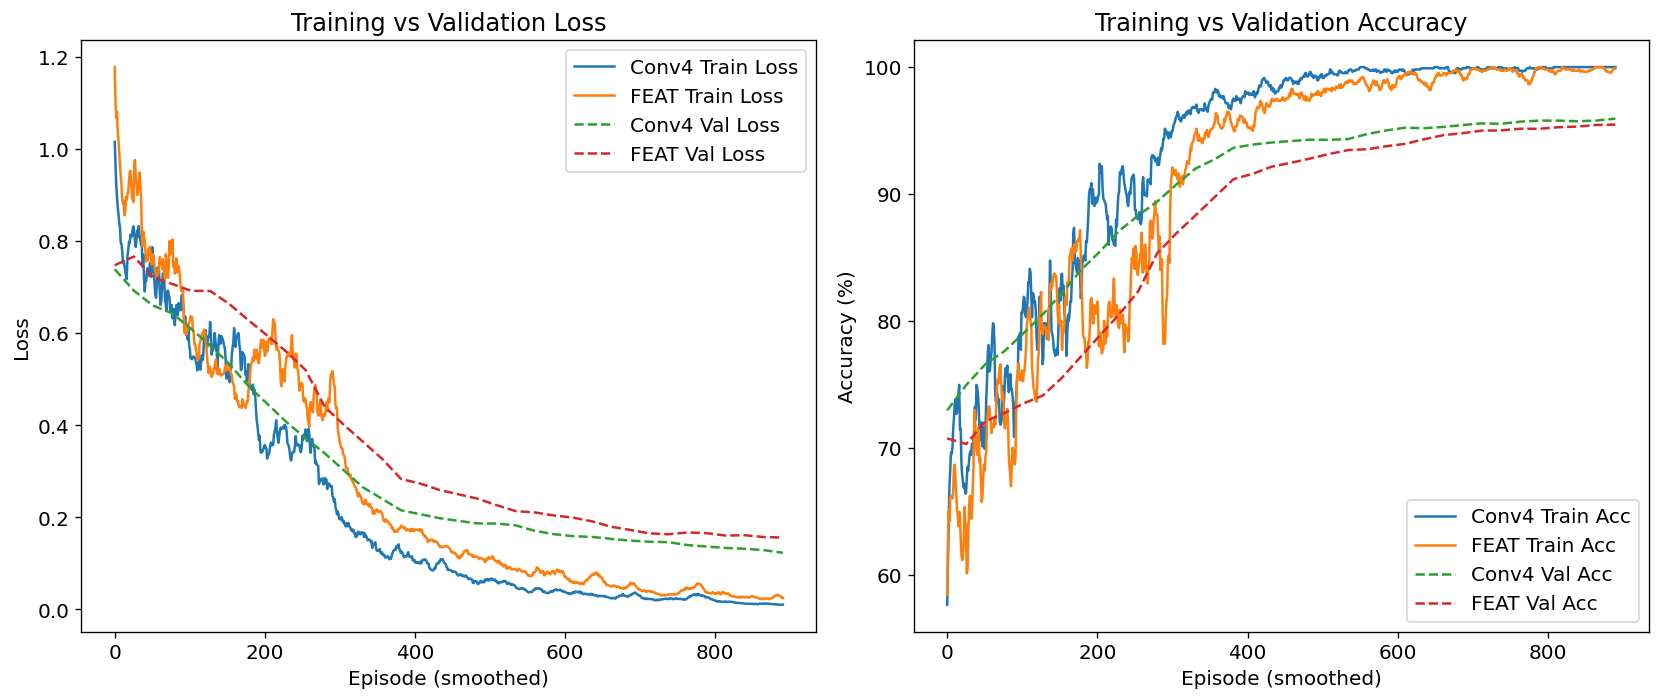

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({'font.size': 12})
def smooth(x, window_len=10):
    if len(x) < window_len:
        return np.array(x)
    return np.convolve(x, np.ones(window_len)/window_len, mode='valid')

plt.figure(figsize=(14,6), dpi=120)
plt.subplot(1,2,1)
plt.plot(smooth(history_protonet['loss']), label='Conv4 Train Loss')
plt.plot(smooth(history_feat['loss']), label='FEAT Train Loss')
if history_protonet['val_loss']:
    plt.plot(np.linspace(0, len(smooth(history_protonet['loss']))-1, len(smooth(history_protonet['val_loss']))) , smooth(history_protonet['val_loss']), '--', label='Conv4 Val Loss')
if history_feat['val_loss']:
    plt.plot(np.linspace(0, len(smooth(history_feat['loss']))-1, len(smooth(history_feat['val_loss']))) , smooth(history_feat['val_loss']), '--', label='FEAT Val Loss')
plt.xlabel('Episode (smoothed)'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(smooth([a*100 for a in history_protonet['acc']]), label='Conv4 Train Acc')
plt.plot(smooth([a*100 for a in history_feat['acc']]), label='FEAT Train Acc')
if history_protonet['val_acc']:
    plt.plot(np.linspace(0, len(smooth(history_protonet['acc']))-1, len(smooth(history_protonet['val_acc']))) , np.array(smooth(history_protonet['val_acc']))*100, '--', label='Conv4 Val Acc')
if history_feat['val_acc']:
    plt.plot(np.linspace(0, len(smooth(history_feat['acc']))-1, len(smooth(history_feat['val_acc']))) , np.array(smooth(history_feat['val_acc']))*100, '--', label='FEAT Val Acc')
plt.xlabel('Episode (smoothed)'); plt.ylabel('Accuracy (%)'); plt.title('Training vs Validation Accuracy'); plt.legend()
plt.tight_layout()
plt.show()


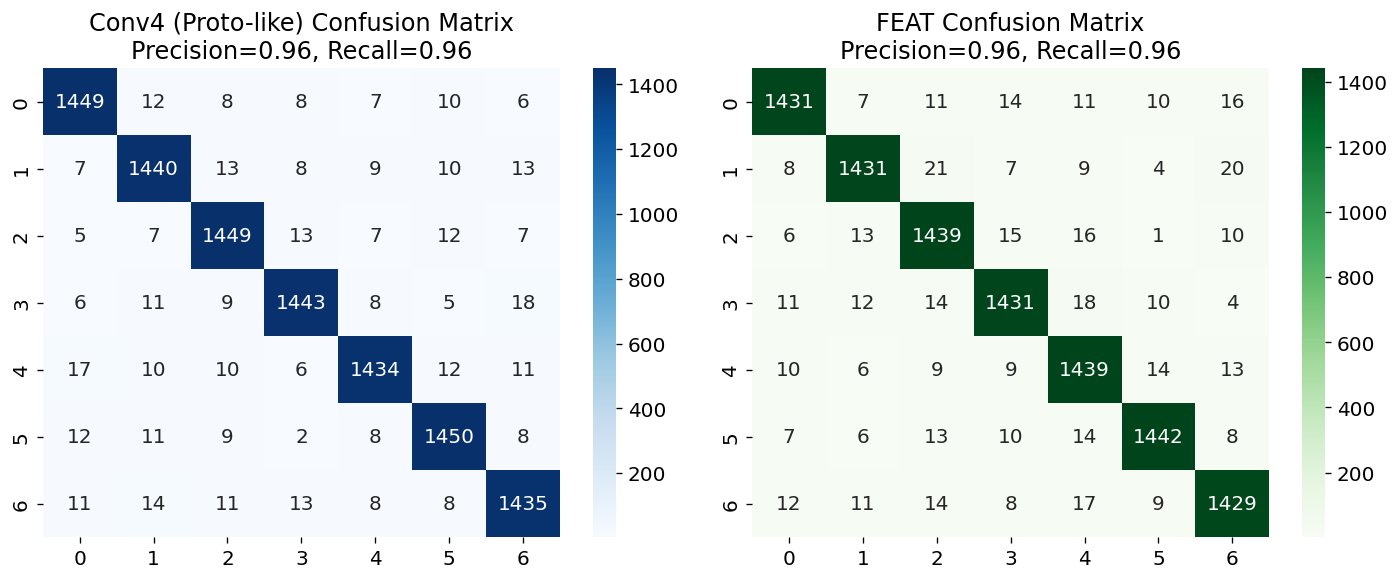

In [ ]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score

def evaluate_model_on_val(model, feat_adapter=None, dataset=val_dataset, N_way=7, K_shot=5, Q_query=15, is_feat=False, episodes_eval=50):
    y_true, y_pred = [], []
    for _ in range(episodes_eval):
        support_paths, support_labels, query_paths, query_labels = dataset.sample_episode(N_way=N_way, K_shot=K_shot, Q_query=Q_query)
        support_images = load_images(support_paths, transform).to(device)
        query_images   = load_images(query_paths, transform).to(device)
        support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
        query_labels_t   = torch.tensor(query_labels, dtype=torch.long).to(device)
        with torch.no_grad():
            if is_feat:
                emb_support = model(support_images)
                prototypes_init = compute_prototypes_for_feat(emb_support, support_labels_t, N_way)
                prototypes_adapted = feat_adapter(prototypes_init)
                emb_query = model(query_images)
                dists = torch.cdist(emb_query, prototypes_adapted)
                preds = torch.argmin(dists, dim=1)
            else:
                emb_support = model(support_images)
                prototypes = compute_prototypes(emb_support, support_labels_t, N_way, K_shot)
                emb_query = model(query_images)
                dists = torch.cdist(emb_query, prototypes)
                preds = torch.argmin(dists, dim=1)
        y_true.extend(query_labels_t.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return cm, precision, recall

cm_proto, prec_proto, rec_proto = evaluate_model_on_val(model, is_feat=False, N_way=N_way, K_shot=5, Q_query=Q_query, episodes_eval=100)
cm_feat, prec_feat, rec_feat = evaluate_model_on_val(feat_model, feat_adapter, is_feat=True, N_way=N_way, K_shot=5, Q_query=Q_query, episodes_eval=100)

plt.figure(figsize=(12,5), dpi=120)
plt.subplot(1,2,1)
sns.heatmap(cm_proto, annot=True, fmt='d', cmap='Blues')
plt.title(f'Conv4 (Proto-like) Confusion Matrix\nPrecision={prec_proto:.2f}, Recall={rec_proto:.2f}')
plt.subplot(1,2,2)
sns.heatmap(cm_feat, annot=True, fmt='d', cmap='Greens')
plt.title(f'FEAT Confusion Matrix\nPrecision={prec_feat:.2f}, Recall={rec_feat:.2f}')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">
مصورسازی و مقایسه دو مدل در مرحله validation-test با دو معیار ارزیابی loss و accuracy

</div>

Running Validation Episodes...


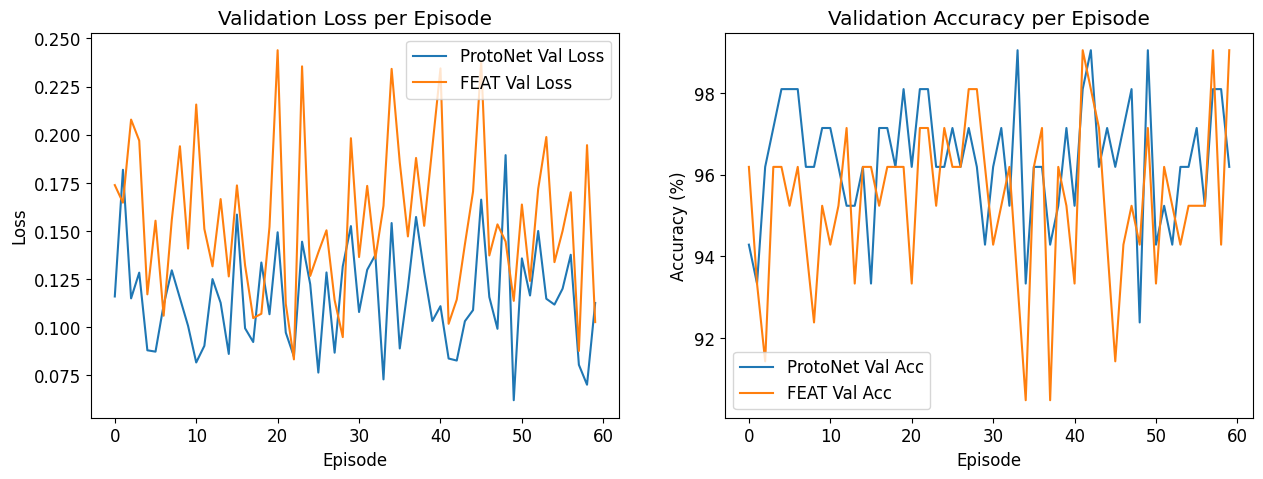


Running TEST Evaluation...


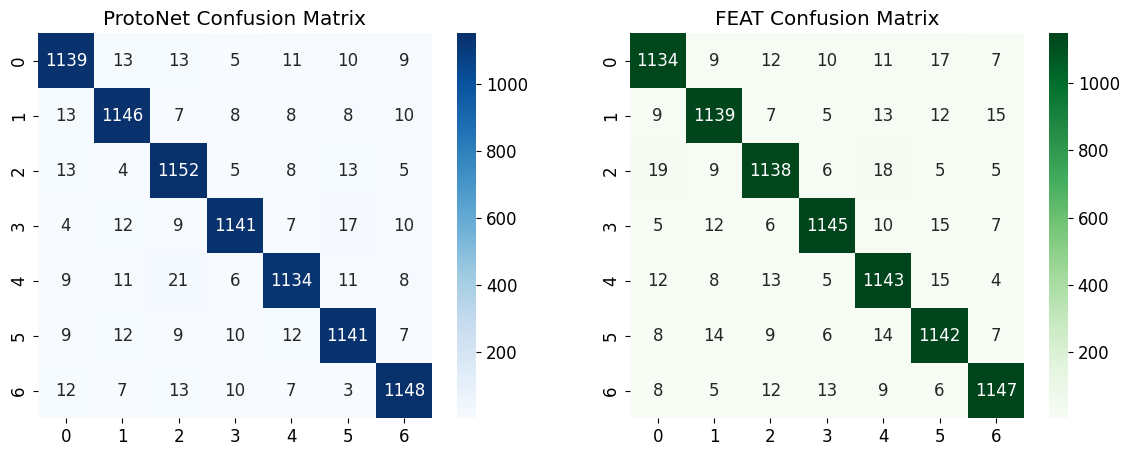


===== ProtoNet Classification Report =====
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1200
           1       0.95      0.95      0.95      1200
           2       0.94      0.96      0.95      1200
           3       0.96      0.95      0.96      1200
           4       0.96      0.94      0.95      1200
           5       0.95      0.95      0.95      1200
           6       0.96      0.96      0.96      1200

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400


===== FEAT Classification Report =====
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1200
           1       0.95      0.95      0.95      1200
           2       0.95      0.95      0.95      1200
           3       0.96      0.95      0.96      1200
           4       0.94      0.95      0.95     

In [ ]:


import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


val_losses_protonet = []
val_accs_protonet = []

val_losses_feat = []
val_accs_feat = []

VAL_EPISODES = 60

print("Running Validation Episodes...")

for episode in range(VAL_EPISODES):

   
    support_paths, support_labels, query_paths, query_labels = \
        val_dataset.sample_episode(N_way=N_way, K_shot=5, Q_query=Q_query)

    support_images = load_images(support_paths, transform).to(device)
    query_images   = load_images(query_paths, transform).to(device)

    support_labels_t = torch.tensor(support_labels).to(device)
    query_labels_t   = torch.tensor(query_labels).to(device)

    
    with torch.no_grad():
        emb_support = model(support_images)
        prototypes = compute_prototypes(emb_support, support_labels_t, N_way, 5)

        emb_query = model(query_images)
        loss_p, acc_p = prototypical_loss(prototypes, emb_query, query_labels_t)

        val_losses_protonet.append(loss_p.item())
        val_accs_protonet.append(acc_p)

    
    with torch.no_grad():
        emb_support_f = feat_model(support_images)
        proto_init = compute_prototypes_for_feat(emb_support_f, support_labels_t, N_way)

        proto_adapted = feat_adapter(proto_init)

        emb_query_f = feat_model(query_images)
        loss_f, acc_f = prototypical_loss_feat(proto_adapted, emb_query_f, query_labels_t)

        val_losses_feat.append(loss_f.item())
        val_accs_feat.append(acc_f)



plt.figure(figsize=(15,5))


plt.subplot(1,2,1)
plt.plot(val_losses_protonet, label="ProtoNet Val Loss")
plt.plot(val_losses_feat, label="FEAT Val Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("Validation Loss per Episode")
plt.legend()


plt.subplot(1,2,2)
plt.plot([x*100 for x in val_accs_protonet], label="ProtoNet Val Acc")
plt.plot([x*100 for x in val_accs_feat], label="FEAT Val Acc")
plt.xlabel("Episode")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy per Episode")
plt.legend()

plt.show()




print("\nRunning TEST Evaluation...")

y_true = []
y_pred_proto = []
y_pred_feat  = []

TEST_EPISODES = 80

for _ in range(TEST_EPISODES):

    support_paths, support_labels, query_paths, query_labels = \
        test_dataset.sample_episode(N_way=N_way, K_shot=5, Q_query=Q_query)

    support_images = load_images(support_paths, transform).to(device)
    query_images   = load_images(query_paths, transform).to(device)

    support_labels_t = torch.tensor(support_labels).to(device)
    query_labels_t   = torch.tensor(query_labels).to(device)

   
    with torch.no_grad():
        emb_sup = model(support_images)
        proto = compute_prototypes(emb_sup, support_labels_t, N_way, 5)

        emb_q = model(query_images)
        dists = torch.cdist(emb_q, proto)
        preds = torch.argmin(dists, dim=1)

    y_true.extend(query_labels)
    y_pred_proto.extend(preds.cpu().numpy())

    
    with torch.no_grad():
        emb_sup_f = feat_model(support_images)
        proto_init = compute_prototypes_for_feat(emb_sup_f, support_labels_t, N_way)
        proto_adapt = feat_adapter(proto_init)

        emb_q_f = feat_model(query_images)
        dists_f = torch.cdist(emb_q_f, proto_adapt)
        preds_f = torch.argmin(dists_f, dim=1)

    y_pred_feat.extend(preds_f.cpu().numpy())



plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
cm_p = confusion_matrix(y_true, y_pred_proto)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues')
plt.title("ProtoNet Confusion Matrix")


plt.subplot(1,2,2)
cm_f = confusion_matrix(y_true, y_pred_feat)
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Greens')
plt.title("FEAT Confusion Matrix")

plt.show()



print("\n===== ProtoNet Classification Report =====")
print(classification_report(y_true, y_pred_proto))

print("\n===== FEAT Classification Report =====")
print(classification_report(y_true, y_pred_feat))




<div dir="rtl" style="text-align:right; font-family: 'Vazirmatn','Tahoma';">
ایجاد آپلودر برای تست عکس های خارج از دیتاست
</div>

Saving WhatsApp Image 2025-12-07 at 13.04.25.jpeg to WhatsApp Image 2025-12-07 at 13.04.25 (5).jpeg
Image uploaded: WhatsApp Image 2025-12-07 at 13.04.25 (5).jpeg


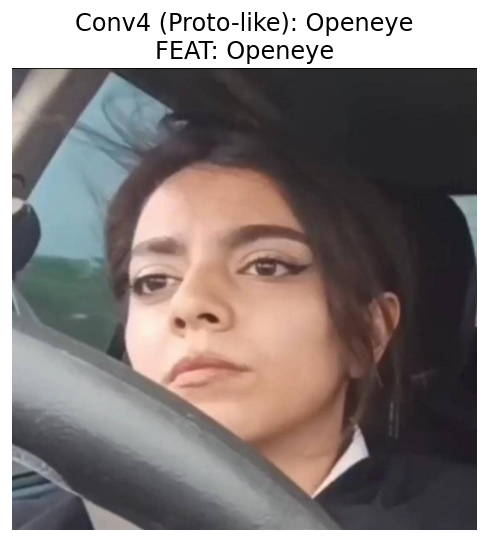

In [ ]:


from google.colab import files as files2
import matplotlib.pyplot as plt
uploaded = files2.upload()
test_image_path = list(uploaded.keys())[0]
print("Image uploaded:", test_image_path)

support_root = "driver_split/train"
N_way = 7
K_shot = 10
class_names = sorted([d for d in os.listdir(support_root) if os.path.isdir(os.path.join(support_root, d))])

support_paths = []
support_labels = []
for label, cls in enumerate(class_names[:N_way]):
    cls_path = os.path.join(support_root, cls)
    imgs = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))][:K_shot]
    for img in imgs:
        support_paths.append(os.path.join(cls_path, img))
        support_labels.append(label)

def predict_image_protonet(model, prototypes, class_names, image_path, transform):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(img_t)
        dists = torch.cdist(emb, prototypes)
        pred_label = torch.argmin(dists, dim=1).item()
    return class_names[pred_label]

support_images_conv4 = load_images(support_paths, transform).to(device)
support_labels_conv4 = torch.tensor(support_labels, dtype=torch.long).to(device)
with torch.no_grad():
    emb_support_conv4 = model(support_images_conv4)
prototypes_conv4 = compute_prototypes(emb_support_conv4, support_labels_conv4, N_way, K_shot)

def predict_image_feat(feat_model, feat_adapter, support_paths, support_labels, image_path, class_names, transform):
    feat_model.eval(); feat_adapter.eval()
    support_images = load_images(support_paths, transform).to(device)
    support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
    with torch.no_grad():
        emb_support = feat_model(support_images)
        prototypes_init = compute_prototypes_for_feat(emb_support, support_labels_t, N_way=len(torch.unique(support_labels_t)))
        prototypes_adapted = feat_adapter(prototypes_init)
        img = Image.open(image_path).convert("RGB")
        img_t = transform(img).unsqueeze(0).to(device)
        emb = feat_model(img_t)
        dists = torch.cdist(emb, prototypes_adapted)
        pred_label = torch.argmin(dists, dim=1).item()
    return class_names[pred_label]

pred_conv4 = predict_image_protonet(model, prototypes_conv4, class_names[:N_way], test_image_path, transform)
pred_feat = predict_image_feat(feat_model, feat_adapter, support_paths, support_labels, test_image_path, class_names[:N_way], transform)

img = Image.open(test_image_path).convert("RGB")
plt.figure(figsize=(5,5), dpi=120)
plt.imshow(img)
plt.axis('off')
plt.title(f"Conv4 (Proto-like): {pred_conv4}\nFEAT: {pred_feat}")
plt.show()


Saving gA_1_s1_ir_face_mp4-50_jpg.rf.d6348bb05d526c58e2546c6f7e801cff.jpg to gA_1_s1_ir_face_mp4-50_jpg.rf.d6348bb05d526c58e2546c6f7e801cff (1).jpg
Image uploaded: gA_1_s1_ir_face_mp4-50_jpg.rf.d6348bb05d526c58e2546c6f7e801cff (1).jpg


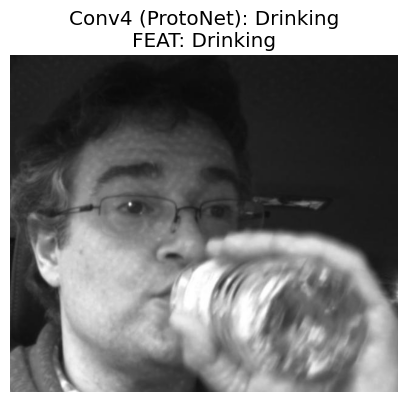

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
import os

uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]
print("Image uploaded:", test_image_path)

support_root = "driver_split/train"
N_way = 7
K_shot = 15
class_names = sorted(os.listdir(support_root))

support_paths = []
support_labels = []
for label, cls in enumerate(class_names[:N_way]):
    cls_path = os.path.join(support_root, cls)
    imgs = os.listdir(cls_path)[:K_shot]
    for img in imgs:
        support_paths.append(os.path.join(cls_path, img))
        support_labels.append(label)

def predict_image_protonet(model, prototypes, class_names, image_path, transform):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(img_t)  
        dists = torch.cdist(emb, prototypes)  
        pred_label = torch.argmin(dists, dim=1).item()
    return class_names[pred_label]

support_images_conv4 = load_images(support_paths, transform).to(device)
support_labels_conv4 = torch.tensor(support_labels, dtype=torch.long).to(device)
with torch.no_grad():
    emb_support_conv4 = model(support_images_conv4)
prototypes_conv4 = compute_prototypes(emb_support_conv4, support_labels_conv4, N_way, K_shot)

def predict_image_feat(feat_model, feat_adapter, support_paths, support_labels, image_path, class_names, transform):
    feat_model.eval()
    feat_adapter.eval()
    support_images = load_images(support_paths, transform).to(device)
    support_labels_t = torch.tensor(support_labels, dtype=torch.long).to(device)
    with torch.no_grad():
        emb_support = feat_model(support_images)
        prototypes_init = compute_prototypes_for_feat(emb_support, support_labels_t, N_way=len(torch.unique(support_labels_t)))
        prototypes_adapted = feat_adapter(prototypes_init)
        img = Image.open(image_path).convert("RGB")
        img_t = transform(img).unsqueeze(0).to(device)
        emb = feat_model(img_t)
        dists = torch.cdist(emb, prototypes_adapted)
        pred_label = torch.argmin(dists, dim=1).item()
    return class_names[pred_label]

pred_conv4 = predict_image_protonet(model, prototypes_conv4, class_names[:N_way], test_image_path, transform)
pred_feat = predict_image_feat(feat_model, feat_adapter, support_paths, support_labels, test_image_path, class_names[:N_way], transform)

img = Image.open(test_image_path).convert("RGB")
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Conv4 (ProtoNet): {pred_conv4}\nFEAT: {pred_feat}")
plt.show()
